In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
!tar -xzf "/content/drive/MyDrive/CodecRobust/processed_upload.tar.gz" -C /content/
print("Done.")
!ls /content/uncompressed/dev/ | head -3

Done.
LA_D_1006568.pt
LA_D_1008730.pt
LA_D_1010295.pt


In [3]:
!git clone https://github.com/roh1thbharathi/applied-dl-project-2.git
%cd /content/applied-dl-project-2
!pip install -q -r requirements.txt

import sys
sys.path.insert(0, '/content/applied-dl-project-2/src')
print("Done.")

Cloning into 'applied-dl-project-2'...
remote: Enumerating objects: 72, done.
remote: Counting objects: 100% (72/72), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 72 (delta 22), reused 57 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (72/72), 72.18 KiB | 2.49 MiB/s, done.
Resolving deltas: 100% (22/22), done.
/content/applied-dl-project-2
Done.


In [4]:
import os
from pathlib import Path
import data_utils

original_init = data_utils.ASVspoof2019Preprocessed.__init__

def patched_init(self, asv_root, processed_root, split="train", contrastive=False):
    original_init(self, asv_root, processed_root, split, contrastive)
    available = set(
        f.replace('.pt', '')
        for f in os.listdir(Path(processed_root) / 'uncompressed' / split)
    )
    before = len(self.records)
    self.records = self.records[self.records['filename'].isin(available)].reset_index(drop=True)
    print(f"  [Filter] {split}: {before} → {len(self.records)} (matched preprocessed files)")

data_utils.ASVspoof2019Preprocessed.__init__ = patched_init
print("Patch applied.")

Patch applied.


In [5]:
ASV_ROOT       = "/content/asvspoof"
PROCESSED_ROOT = "/content"
print("Paths set.")

Paths set.


In [6]:
# Reload everything fresh
import sys, os, importlib
from pathlib import Path

# Paths
ASV_ROOT       = "/content/asvspoof"
PROCESSED_ROOT = "/content"

# Apply patches
for mod in list(sys.modules.keys()):
    if mod in ['model', 'data_utils', 'evaluate']:
        del sys.modules[mod]

# Fix model.py
with open('/content/applied-dl-project-2/src/model.py', 'r') as f:
    content = f.read()

if 'use_temporal_attn' not in content:
    content = content.replace(
        "    def __init__(self, embed_dim=256, sinc_ch=70, sample_rate=16000, n_attn_heads=4):\n        super().__init__()\n        self.sinc",
        "    def __init__(self, embed_dim=256, sinc_ch=70, sample_rate=16000, n_attn_heads=4, use_temporal_attn=True):\n        super().__init__()\n        self.use_temporal_attn = use_temporal_attn\n        self.sinc"
    )
    content = content.replace(
        "        r    = self.temporal_attn(r)      # (B, 32, 128) — codec-robust focus",
        "        if self.use_temporal_attn:\n            r = self.temporal_attn(r)"
    )
    content = content.replace(
        "    def __init__(self, embed_dim=256, n_codec_classes=10, sample_rate=16000, n_attn_heads=4):\n        super().__init__()\n        # TemporalAttention is now INSIDE AASISTEncoder (on 32 nodes before pool)\n        self.encoder = AASISTEncoder(embed_dim=embed_dim, sample_rate=sample_rate,\n                                     n_attn_heads=n_attn_heads)",
        "    def __init__(self, embed_dim=256, n_codec_classes=10, sample_rate=16000, n_attn_heads=4, use_temporal_attn=True):\n        super().__init__()\n        self.encoder = AASISTEncoder(embed_dim=embed_dim, sample_rate=sample_rate,\n                                     n_attn_heads=n_attn_heads, use_temporal_attn=use_temporal_attn)"
    )
    with open('/content/applied-dl-project-2/src/model.py', 'w') as f:
        f.write(content)

sys.path.insert(0, '/content/applied-dl-project-2/src')

import torch
from model import CodecRobustDetector
from data_utils import N_CODEC_CLASSES

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_model(path, use_temporal_attn=True):
    m = CodecRobustDetector(embed_dim=256, n_codec_classes=N_CODEC_CLASSES,
                            use_temporal_attn=use_temporal_attn).to(device)
    state = torch.load(path, map_location=device)
    if isinstance(state, dict) and 'model_state_dict' in state:
        m.load_state_dict(state['model_state_dict'])
    else:
        m.load_state_dict(state)
    m.eval()
    return m

checkpoint_map = {
    "Vanilla":   "/content/drive/MyDrive/CodecRobust/results/vanilla/best_model.pt",
    "+Temporal": "/content/drive/MyDrive/Applied-DL-2/trained_models/base_best_model.pt",
    "+GRL+Con":  "/content/drive/MyDrive/CodecRobust/results/grl_contrastive_no_temporal/best_model.pt",
    "Full":      "/content/drive/MyDrive/Applied-DL-2/trained_models/full_best_model.pt",
}

vanilla  = load_model(checkpoint_map["Vanilla"],   use_temporal_attn=False)
temporal = load_model(checkpoint_map["+Temporal"], use_temporal_attn=True)
grl_con  = load_model(checkpoint_map["+GRL+Con"],  use_temporal_attn=False)
full     = load_model(checkpoint_map["Full"],      use_temporal_attn=True)

models_dict = {"Vanilla": vanilla, "+Temporal": temporal, "+GRL+Con": grl_con, "Full": full}
print("All 4 models loaded.")

All 4 models loaded.


In [9]:
import shutil, os

os.makedirs("/content/asvspoof/LA/ASVspoof2019_LA_cm_protocols", exist_ok=True)

for fname in ['ASVspoof2019.LA.cm.train.trn.txt',
              'ASVspoof2019.LA.cm.dev.trl.txt',
              'ASVspoof2019.LA.cm.eval.trl.txt']:
    shutil.copy(
        f"/content/drive/MyDrive/CodecRobust/protocols/LA/ASVspoof2019_LA_cm_protocols/{fname}",
        f"/content/asvspoof/LA/ASVspoof2019_LA_cm_protocols/{fname}"
    )
print("Done.")

Done.


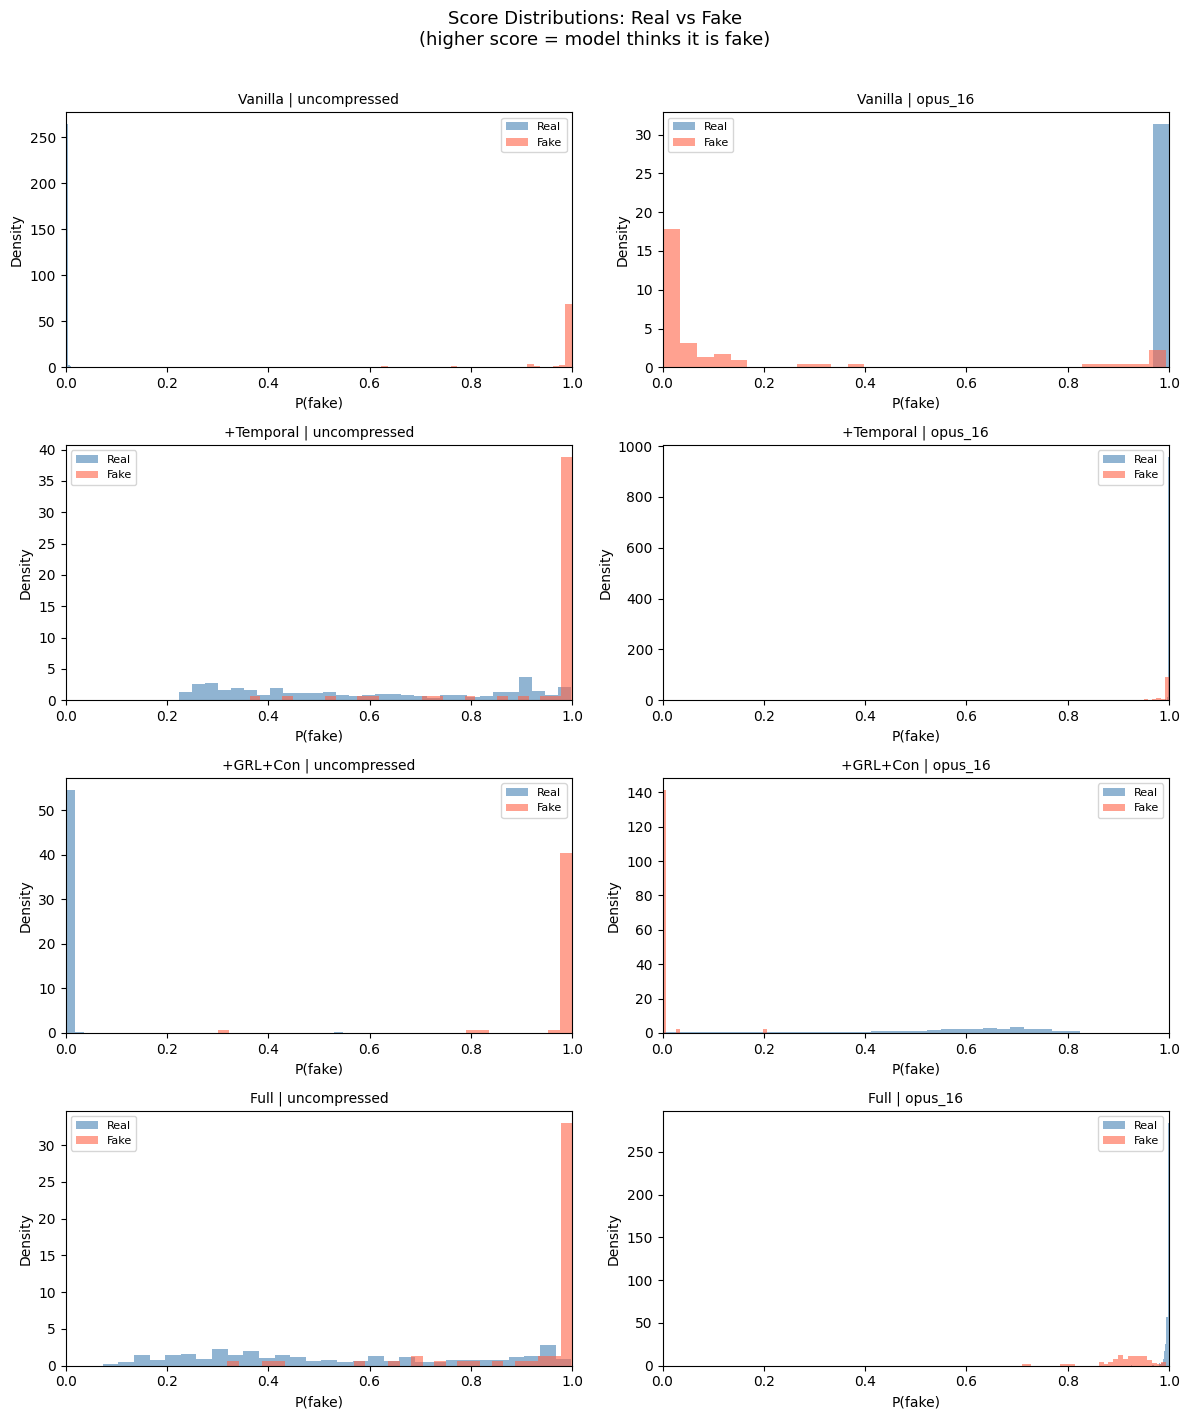

Saved to Drive.


In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from data_utils import apply_codec, codec_tag

# Load dev samples
proto_path = Path(ASV_ROOT) / 'LA' / 'ASVspoof2019_LA_cm_protocols' / 'ASVspoof2019.LA.cm.dev.trl.txt'
df = pd.read_csv(proto_path, sep=' ', header=None,
                 names=['speaker','filename','dash','system_id','label'])
import os
available = set(f.replace('.pt','') for f in os.listdir(f'{PROCESSED_ROOT}/uncompressed/dev/'))
df = df[df['filename'].isin(available)].reset_index(drop=True)
df = df.sample(500, random_state=42).reset_index(drop=True)

# Evaluate on two conditions: uncompressed and opus_16
conditions = [('uncompressed', None), ('opus', 16)]

fig, axes = plt.subplots(len(models_dict), len(conditions),
                          figsize=(12, 14), sharey=False)
fig.suptitle('Score Distributions: Real vs Fake\n(higher score = model thinks it is fake)',
             fontsize=13, y=1.01)

for col, (codec, bitrate) in enumerate(conditions):
    # Compress all audio once
    all_wfs, all_labs = [], []
    for _, row in df.iterrows():
        pt = Path(PROCESSED_ROOT) / 'uncompressed' / 'dev' / f"{row['filename']}.pt"
        if not pt.exists(): continue
        wav = torch.load(pt, weights_only=True).unsqueeze(0)
        wav = apply_codec(wav, 16000, codec, bitrate)
        all_wfs.append(wav.squeeze(0))
        all_labs.append(0 if row['label'] == 'bonafide' else 1)
    all_labs = np.array(all_labs)

    for row_idx, (name, model) in enumerate(models_dict.items()):
        scores = []
        for i in range(0, len(all_wfs), 32):
            batch = torch.stack(all_wfs[i:i+32]).to(device)
            with torch.no_grad():
                s = torch.softmax(model(batch)['deepfake_logits'], -1)[:, 1]
            scores.extend(s.cpu().numpy())
        scores = np.array(scores)

        ax = axes[row_idx][col]
        ax.hist(scores[all_labs==0], bins=30, alpha=0.6, color='steelblue',
                label='Real', density=True)
        ax.hist(scores[all_labs==1], bins=30, alpha=0.6, color='tomato',
                label='Fake', density=True)
        ax.set_title(f"{name} | {codec_tag(codec, bitrate)}", fontsize=10)
        ax.set_xlabel("P(fake)")
        ax.set_ylabel("Density")
        ax.legend(fontsize=8)
        ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CodecRobust/score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to Drive.")

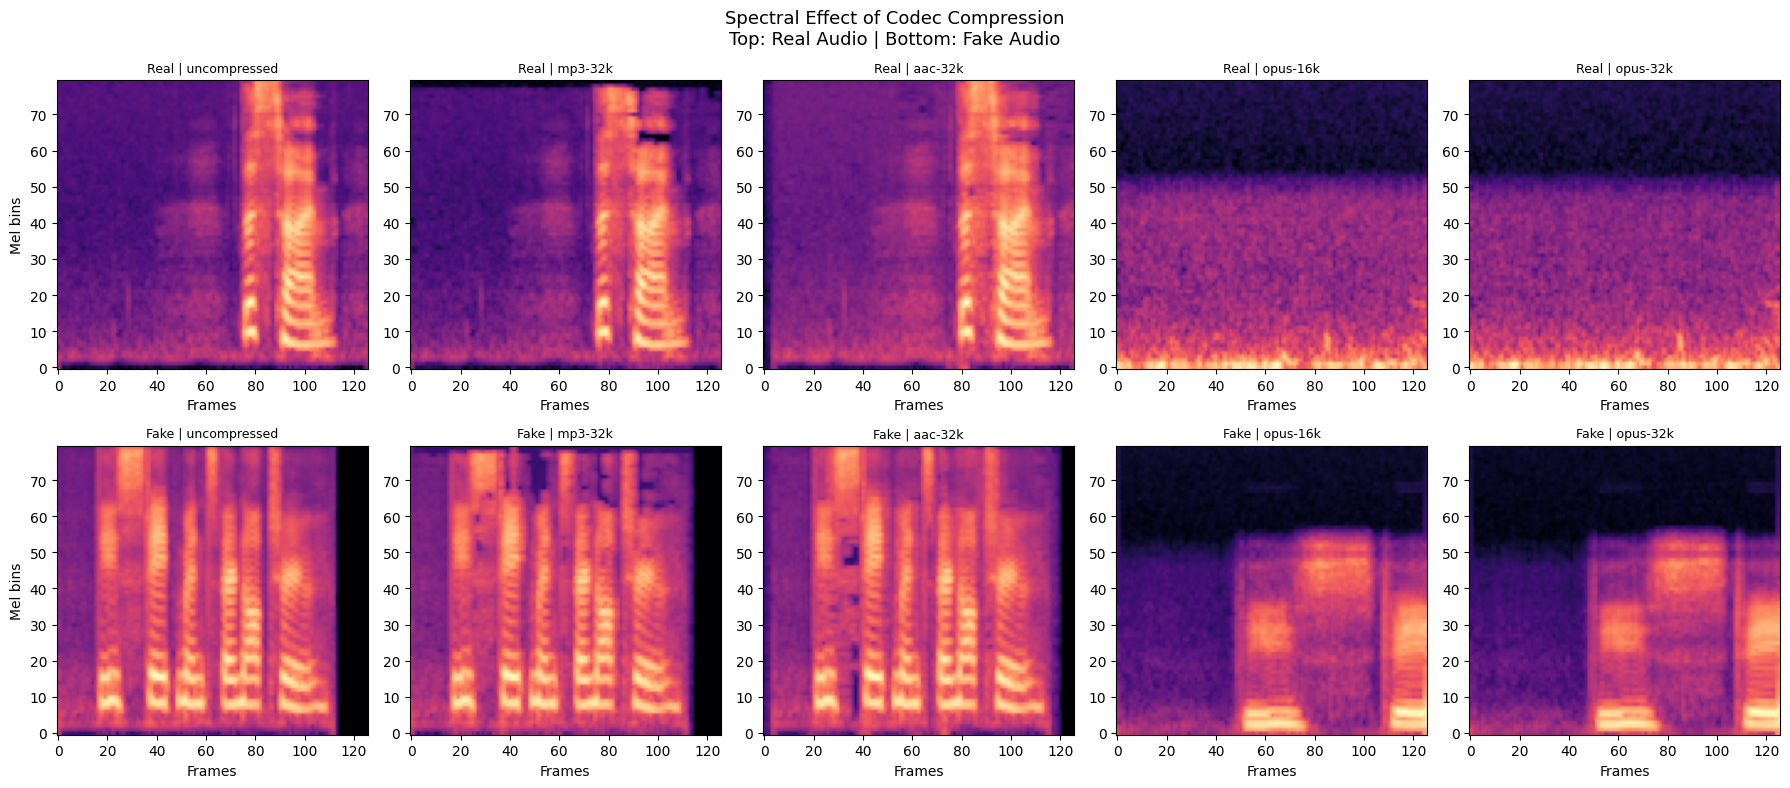

Saved to Drive.


In [15]:
import matplotlib.pyplot as plt
import torch
import torchaudio
import torchaudio.transforms as T
from pathlib import Path
from data_utils import apply_codec
import os

# Pick one bonafide and one spoof sample
import pandas as pd
proto_path = Path(ASV_ROOT) / 'LA' / 'ASVspoof2019_LA_cm_protocols' / 'ASVspoof2019.LA.cm.dev.trl.txt'
df = pd.read_csv(proto_path, sep=' ', header=None,
                 names=['speaker','filename','dash','system_id','label'])
available = set(f.replace('.pt','') for f in os.listdir(f'{PROCESSED_ROOT}/uncompressed/dev/'))
df = df[df['filename'].isin(available)].reset_index(drop=True)

bonafide_file = df[df['label']=='bonafide'].iloc[0]['filename']
spoof_file    = df[df['label']=='spoof'].iloc[0]['filename']

conditions = [
    ('uncompressed', None),
    ('mp3', 32),
    ('aac', 32),
    ('opus', 16),
    ('opus', 32),
]

mel = T.MelSpectrogram(sample_rate=16000, n_fft=1024, hop_length=256, n_mels=80)

fig, axes = plt.subplots(2, len(conditions), figsize=(18, 8))
fig.suptitle('Spectral Effect of Codec Compression\nTop: Real Audio | Bottom: Fake Audio', fontsize=13)

for col, (codec, bitrate) in enumerate(conditions):
    for row, (label, fname) in enumerate([('Real', bonafide_file), ('Fake', spoof_file)]):
        pt  = torch.load(f'{PROCESSED_ROOT}/uncompressed/dev/{fname}.pt', weights_only=True).unsqueeze(0)
        wav = apply_codec(pt, 16000, codec, bitrate)
        db  = 10 * torch.log10(mel(wav) + 1e-9)

        ax = axes[row][col]
        ax.imshow(db[0].numpy(), aspect='auto', origin='lower', cmap='magma')
        tag = f"{codec}" if not bitrate else f"{codec}-{bitrate}k"
        ax.set_title(f"{label} | {tag}", fontsize=9)
        ax.set_xlabel("Frames")
        if col == 0:
            ax.set_ylabel("Mel bins")

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CodecRobust/spectral_diff.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to Drive.")

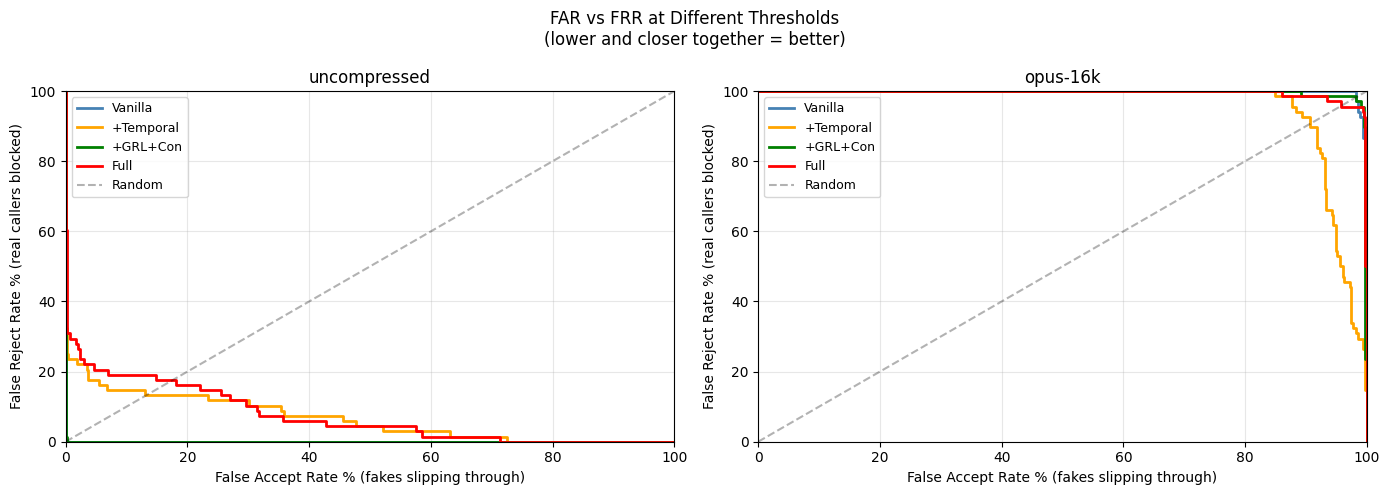

Saved to Drive.


In [16]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from data_utils import apply_codec
from sklearn.metrics import roc_curve

def get_scores_labels(model, wfs, labs, device):
    scores = []
    for i in range(0, len(wfs), 32):
        batch = torch.stack(wfs[i:i+32]).to(device)
        with torch.no_grad():
            s = torch.softmax(model(batch)['deepfake_logits'], -1)[:, 1]
        scores.extend(s.cpu().numpy())
    return np.array(scores), np.array(labs)

# Load samples
import pandas as pd, os
proto_path = Path(ASV_ROOT) / 'LA' / 'ASVspoof2019_LA_cm_protocols' / 'ASVspoof2019.LA.cm.dev.trl.txt'
df = pd.read_csv(proto_path, sep=' ', header=None,
                 names=['speaker','filename','dash','system_id','label'])
available = set(f.replace('.pt','') for f in os.listdir(f'{PROCESSED_ROOT}/uncompressed/dev/'))
df = df[df['filename'].isin(available)].reset_index(drop=True)
df = df.sample(500, random_state=42).reset_index(drop=True)

# Two conditions
conditions = [('uncompressed', None), ('opus', 16)]
colors = {'Vanilla': 'steelblue', '+Temporal': 'orange', '+GRL+Con': 'green', 'Full': 'red'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('FAR vs FRR at Different Thresholds\n(lower and closer together = better)', fontsize=12)

for col, (codec, bitrate) in enumerate(conditions):
    ax = axes[col]

    # Compress audio once
    all_wfs, all_labs = [], []
    for _, row in df.iterrows():
        pt = Path(PROCESSED_ROOT) / 'uncompressed' / 'dev' / f"{row['filename']}.pt"
        if not pt.exists(): continue
        wav = torch.load(pt, weights_only=True).unsqueeze(0)
        wav = apply_codec(wav, 16000, codec, bitrate)
        all_wfs.append(wav.squeeze(0))
        all_labs.append(0 if row['label'] == 'bonafide' else 1)

    for name, model in models_dict.items():
        scores, labs = get_scores_labels(model, all_wfs, all_labs, device)
        fpr, tpr, _ = roc_curve(labs, scores)
        fnr = 1 - tpr
        ax.plot(fpr * 100, fnr * 100, label=name, color=colors[name], linewidth=2)

    ax.plot([0, 100], [0, 100], 'k--', alpha=0.3, label='Random')
    tag = 'uncompressed' if not bitrate else f'opus-{bitrate}k'
    ax.set_title(f'{tag}')
    ax.set_xlabel('False Accept Rate % (fakes slipping through)')
    ax.set_ylabel('False Reject Rate % (real callers blocked)')
    ax.legend(fontsize=9)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CodecRobust/threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to Drive.")

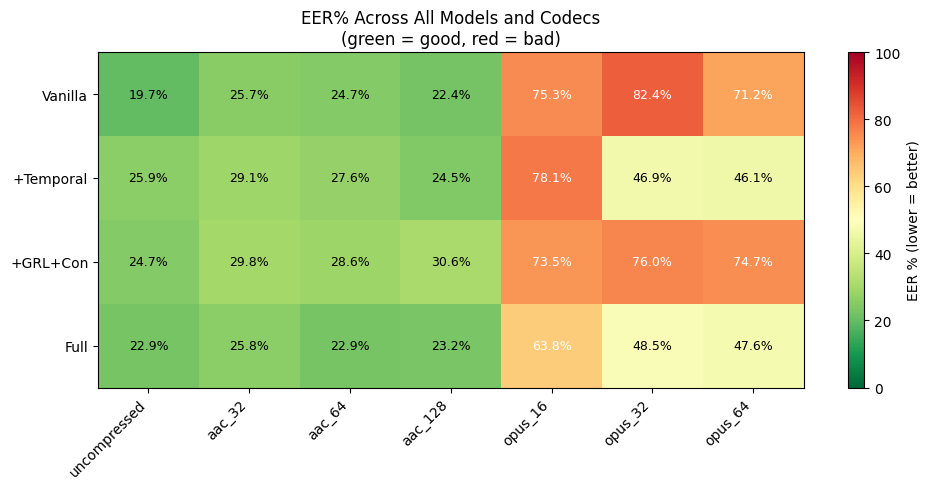

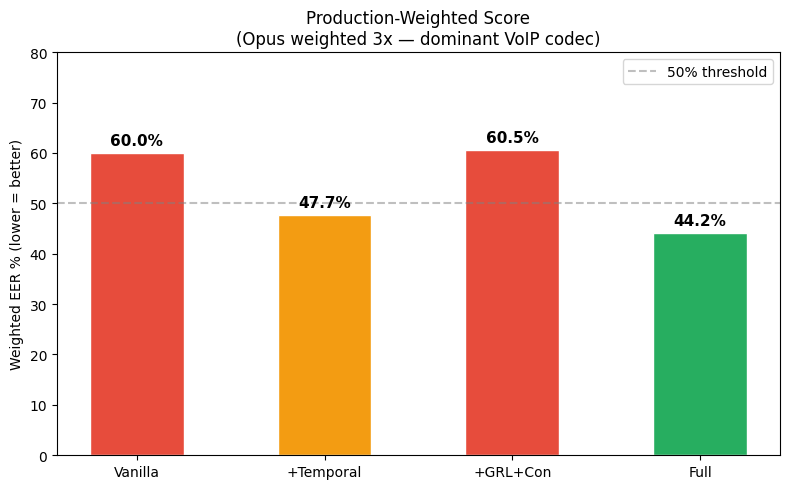

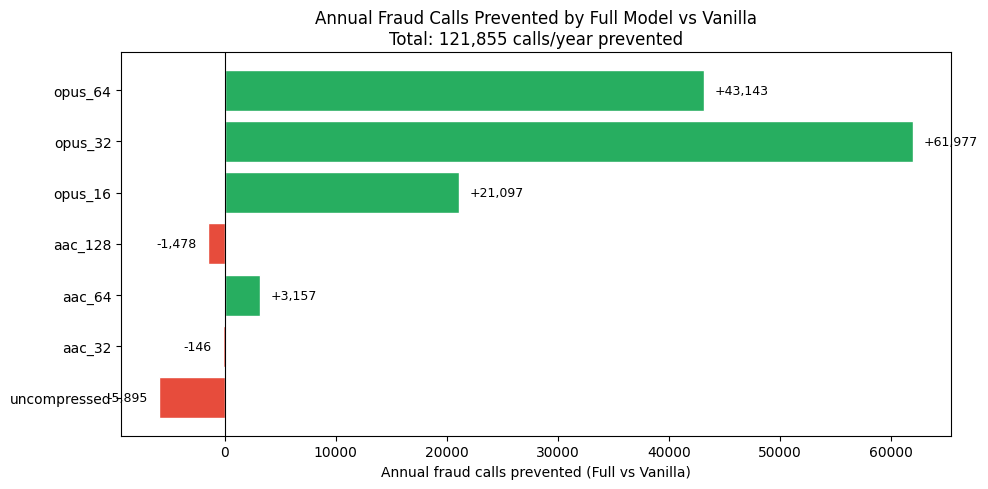

All 3 saved to Drive.


In [17]:
import matplotlib.pyplot as plt
import numpy as np

results = {
    'Vanilla': {
        'uncompressed': 19.72, 'aac_32': 25.71, 'aac_64': 24.67, 'aac_128': 22.42,
        'opus_16': 75.32, 'opus_32': 82.42, 'opus_64': 71.24
    },
    '+Temporal': {
        'uncompressed': 25.89, 'aac_32': 29.11, 'aac_64': 27.58, 'aac_128': 24.46,
        'opus_16': 78.11, 'opus_32': 46.86, 'opus_64': 46.06
    },
    '+GRL+Con': {
        'uncompressed': 24.66, 'aac_32': 29.83, 'aac_64': 28.56, 'aac_128': 30.61,
        'opus_16': 73.45, 'opus_32': 76.01, 'opus_64': 74.74
    },
    'Full': {
        'uncompressed': 22.95, 'aac_32': 25.79, 'aac_64': 22.94, 'aac_128': 23.23,
        'opus_16': 63.76, 'opus_32': 48.46, 'opus_64': 47.60
    }
}

codecs  = list(next(iter(results.values())).keys())
models  = list(results.keys())
matrix  = np.array([[results[m][c] for c in codecs] for m in models])

# ── Plot 1: EER Heatmap ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(matrix, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=100)
plt.colorbar(im, ax=ax, label='EER % (lower = better)')
ax.set_xticks(range(len(codecs)))
ax.set_xticklabels(codecs, rotation=45, ha='right')
ax.set_yticks(range(len(models)))
ax.set_yticklabels(models)
ax.set_title('EER% Across All Models and Codecs\n(green = good, red = bad)', fontsize=12)
for i in range(len(models)):
    for j in range(len(codecs)):
        ax.text(j, i, f'{matrix[i,j]:.1f}%', ha='center', va='center',
                fontsize=9, color='black' if matrix[i,j] < 60 else 'white')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CodecRobust/heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: Production-weighted score ─────────────────────
weights = {'uncompressed': 1, 'aac_32': 1, 'aac_64': 1, 'aac_128': 1,
           'opus_16': 3, 'opus_32': 3, 'opus_64': 3}
total_w = sum(weights.values())
weighted_scores = {m: sum(results[m][c] * weights[c] for c in codecs) / total_w
                   for m in models}

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c', '#f39c12', '#e74c3c', '#27ae60']
bars = ax.bar(models, weighted_scores.values(), color=colors, width=0.5, edgecolor='white')
ax.set_ylabel('Weighted EER % (lower = better)')
ax.set_title('Production-Weighted Score\n(Opus weighted 3x — dominant VoIP codec)', fontsize=12)
ax.set_ylim(0, 80)
for bar, val in zip(bars, weighted_scores.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='50% threshold')
ax.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CodecRobust/weighted_score.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 3: Annual fraud prevented ────────────────────────
DAILY_CALLS = 10000
FAKE_RATE   = 0.05
daily_fakes = DAILY_CALLS * FAKE_RATE

annual_prevented = {}
for codec in codecs:
    v = results['Vanilla'][codec]
    f = results['Full'][codec]
    annual_prevented[codec] = round(daily_fakes * (v - f) / 100 * 365)

fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = ['#27ae60' if v > 0 else '#e74c3c' for v in annual_prevented.values()]
bars = ax.barh(list(annual_prevented.keys()), list(annual_prevented.values()),
               color=colors_bar, edgecolor='white')
ax.set_xlabel('Annual fraud calls prevented (Full vs Vanilla)')
ax.set_title('Annual Fraud Calls Prevented by Full Model vs Vanilla\n(green = improvement, red = regression)', fontsize=12)
ax.axvline(x=0, color='black', linewidth=0.8)
for bar, val in zip(bars, annual_prevented.values()):
    ax.text(val + (1000 if val >= 0 else -1000), bar.get_y() + bar.get_height()/2,
            f'{val:+,}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
total = sum(annual_prevented.values())
ax.set_title(f'Annual Fraud Calls Prevented by Full Model vs Vanilla\nTotal: {total:,} calls/year prevented', fontsize=12)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CodecRobust/annual_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

print("All 3 saved to Drive.")